In [1]:
import pandas as pd

In [3]:
dfgat = pd.read_csv('/home/pkaczyns/Code/ALE-and-GNNs/data/citations/ALE_scalability_GAT_no_khop.csv', header=None, names=['i', 'k', 'max_bin_size', 'ALE exact', 'time_exact', 'ALE approximate', 'time_approximate', 'n_layers', 'hidden_size', 'no_exp', 'trial'])
dfgcn = pd.read_csv('/home/pkaczyns/Code/ALE-and-GNNs/data/citations/ALE_scalability_GCN_no_khop.csv', header=None, names=['i', 'k', 'max_bin_size', 'ALE exact', 'time_exact', 'ALE approximate', 'time_approximate', 'n_layers', 'hidden_size', 'no_exp'])

In [4]:
import numpy as np
dfgcn['trial'] = np.floor(dfgcn.index/5)

In [7]:
df2 = pd.read_csv('/home/pkaczyns/Code/ALE-and-GNNs/data/citations/ALE_scalability_GCN.csv', header=None, names=['i', 'k', 'max_bin_size', 'ALE exact', 'time_exact', 'ALE approximate', 'time_approximate', 'n_layers', 'hidden_size', 'no_exp', 'trial'])

In [7]:
df2 = df2[df2['n_layers']==2]

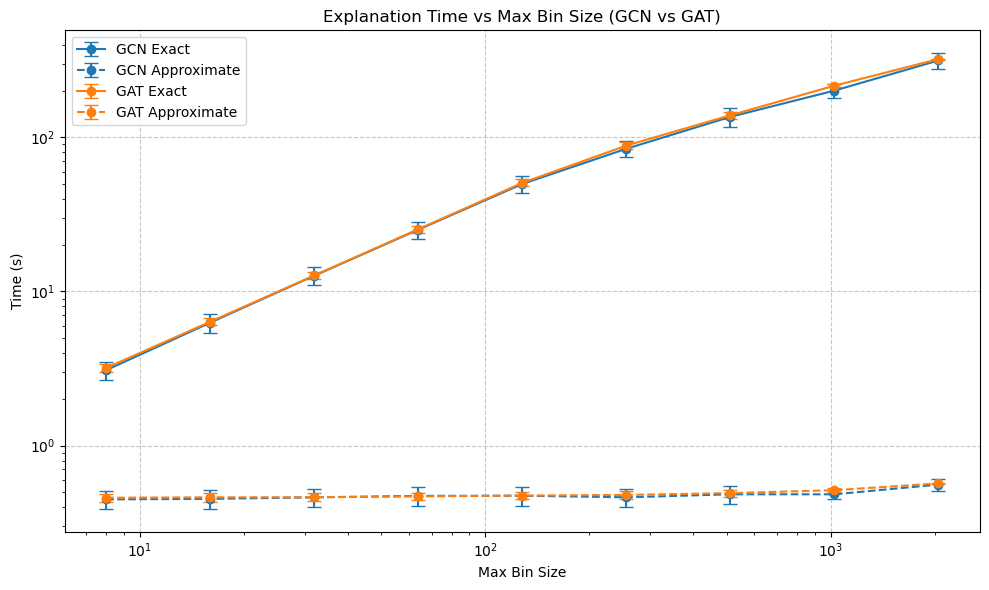

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. DATA PROCESSING FUNCTION
# ---------------------------------------------------------
def get_plot_stats(df):
    """
    Collapses experiment rows and calculates mean/std 
    per max_bin_size.
    """
    # Step A: Aggregate per experiment
    # Group by bin_size and experiment number, taking the mean of time columns
    per_experiment = df.groupby(['max_bin_size', 'no_exp'])[['time_exact', 'time_approximate']].mean().reset_index()
    
    # Step B: Calculate Mean and Error (Std Dev) across the different models
    stats = per_experiment.groupby('max_bin_size')[['time_exact', 'time_approximate']].agg(['mean', 'std'])
    
    # Fill NaN standard deviations with 0
    return stats.fillna(0)

# Process both DataFrames
gcn_stats = get_plot_stats(dfgcn)
gat_stats = get_plot_stats(dfgat)

# 2. PLOTTING
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

# --- PLOT GCN (Blue) ---
# GCN Exact (Solid Line)
plt.errorbar(
    gcn_stats.index, 
    gcn_stats['time_exact']['mean'], 
    yerr=gcn_stats['time_exact']['std'], 
    fmt='o',              # Marker style
    linestyle='-',        # Solid line
    capsize=5, 
    label='GCN Exact', 
    color='tab:blue'
)

# GCN Approximate (Dashed Line)
plt.errorbar(
    gcn_stats.index, 
    gcn_stats['time_approximate']['mean'], 
    yerr=gcn_stats['time_approximate']['std'], 
    fmt='o',              # Marker style
    linestyle='--',       # Dashed line
    capsize=5, 
    label='GCN Approximate', 
    color='tab:blue'
)

# --- PLOT GAT (Orange) ---
# GAT Exact (Solid Line)
plt.errorbar(
    gat_stats.index, 
    gat_stats['time_exact']['mean'], 
    yerr=gat_stats['time_exact']['std'], 
    fmt='o',              # Marker style
    linestyle='-',        # Solid line
    capsize=5, 
    label='GAT Exact', 
    color='tab:orange'
)

# GAT Approximate (Dashed Line)
plt.errorbar(
    gat_stats.index, 
    gat_stats['time_approximate']['mean'], 
    yerr=gat_stats['time_approximate']['std'], 
    fmt='o',              # Marker style
    linestyle='--',       # Dashed line
    capsize=5, 
    label='GAT Approximate', 
    color='tab:orange'
)

# 3. FORMATTING
# ---------------------------------------------------------
plt.xlabel('Max Bin Size')
plt.ylabel('Time (s)')
plt.title('Explanation Time vs Max Bin Size (GCN vs GAT)')

# Log scales for both axes as requested by the style of the previous plot
plt.yscale('log')
plt.xscale('log')

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

In [61]:
import numpy as np
df['explanation'] = np.floor(df.index/5)

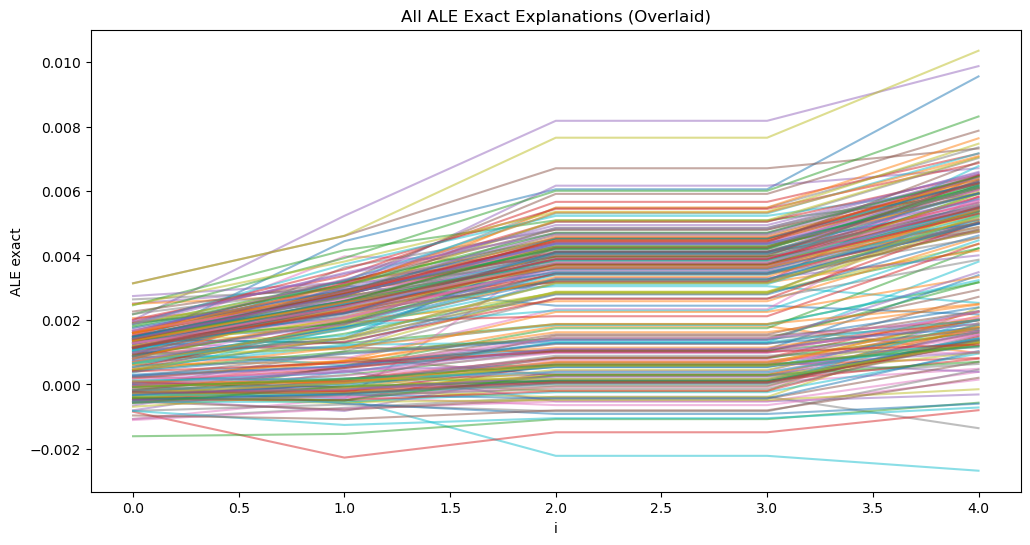

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

# Group the data
groups = df.groupby(['max_bin_size', 'no_exp', 'trial'])

# Iterate and plot each group on the same axis 'ax'
for name, group in groups:
    # We set legend=False to avoid creating a legend with hundreds of entries
    group.plot(x='i', y='ALE approximate', ax=ax, legend=False, alpha=0.5)

plt.ylabel('ALE exact')
plt.title('All ALE Exact Explanations (Overlaid)')
plt.show()

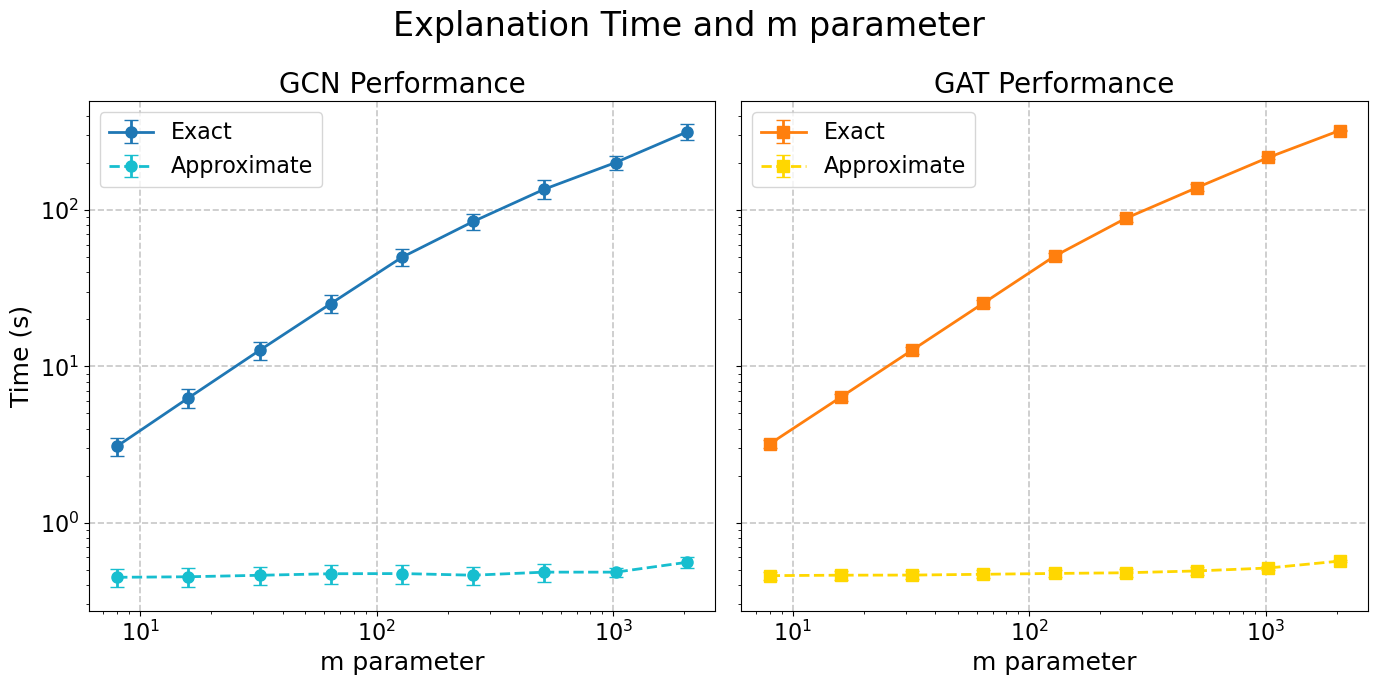

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. GLOBAL FONT CONFIGURATION (Make everything bigger)
# ---------------------------------------------------------
plt.rcParams.update({
    'font.size': 14,          # General text size
    'axes.titlesize': 20,     # Subplot titles (GCN Performance...)
    'axes.labelsize': 18,     # Axis labels (m parameter, Time)
    'xtick.labelsize': 16,    # X-axis tick numbers
    'ytick.labelsize': 16,    # Y-axis tick numbers
    'legend.fontsize': 16,    # Legend text
    'figure.titlesize': 24    # Main Suptitle
})

# 2. DATA PROCESSING FUNCTION
# ---------------------------------------------------------
def get_plot_stats(df):
    per_experiment = df.groupby(['max_bin_size', 'no_exp'])[['time_exact', 'time_approximate']].mean().reset_index()
    stats = per_experiment.groupby('max_bin_size')[['time_exact', 'time_approximate']].agg(['mean', 'std'])
    return stats.fillna(0)

# Assuming dfgcn and dfgat are already loaded
gcn_stats = get_plot_stats(dfgcn)
gat_stats = get_plot_stats(dfgat)

# 3. PLOTTING - SIDE BY SIDE
# ---------------------------------------------------------
# Increased height slightly (14, 7) to accommodate larger text
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7), sharey=True)

# === SUBPLOT 1: GCN ONLY ===
ax1.errorbar(
    gcn_stats.index, 
    gcn_stats['time_exact']['mean'], 
    yerr=gcn_stats['time_exact']['std'], 
    fmt='-o', 
    capsize=5, 
    linewidth=2,       # Thicker lines
    markersize=8,      # Bigger markers
    label='Exact', 
    color='tab:blue'
)

ax1.errorbar(
    gcn_stats.index, 
    gcn_stats['time_approximate']['mean'], 
    yerr=gcn_stats['time_approximate']['std'], 
    fmt='--o', 
    capsize=5, 
    linewidth=2,       # Thicker lines
    markersize=8,      # Bigger markers
    label='Approximate', 
    color='tab:cyan'
)

ax1.set_title("GCN Performance")
ax1.set_ylabel("Time (s)")
ax1.legend(loc="upper left")

# === SUBPLOT 2: GAT ONLY ===
ax2.errorbar(
    gat_stats.index, 
    gat_stats['time_exact']['mean'], 
    yerr=gat_stats['time_exact']['std'], 
    fmt='-s', 
    capsize=5, 
    linewidth=2,       # Thicker lines
    markersize=8,      # Bigger markers
    label='Exact', 
    color='tab:orange'
)

ax2.errorbar(
    gat_stats.index, 
    gat_stats['time_approximate']['mean'], 
    yerr=gat_stats['time_approximate']['std'], 
    fmt='--s', 
    capsize=5, 
    linewidth=2,       # Thicker lines
    markersize=8,      # Bigger markers
    label='Approximate', 
    color='gold'
)

ax2.set_title("GAT Performance")
ax2.legend(loc="upper left")

# 4. GLOBAL FORMATTING
# ---------------------------------------------------------
for ax in [ax1, ax2]:
    ax.set_xlabel('m parameter')
    ax.set_xscale('log')
    ax.set_yscale('log')
    # "which='major'" makes the grid lines match the numbers
    ax.grid(True, linestyle='--', alpha=0.7, which="major", linewidth=1.2)

plt.suptitle('Explanation Time and m parameter') # Added bold for emphasis
plt.tight_layout()
plt.show()

In [7]:
import numpy as np
rmse = df.groupby(['trial', 'no_exp', 'max_bin_size']).apply(lambda x: np.sqrt(np.sum((x['ALE approximate']-x['ALE exact'])**2))).reset_index().rename({0:'rmse'}, axis=1)

/tmp/ipykernel_1847600/3266754304.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmse = df.groupby(['trial', 'no_exp', 'max_bin_size']).apply(lambda x: np.sqrt(np.sum((x['ALE approximate']-x['ALE exact'])**2))).reset_index().rename({0:'rmse'}, axis=1)


In [39]:
rmse.groupby(['max_bin_size'])['rmse'].agg(['mean', 'std'])

,mean,std
max_bin_size,,
8,0.005087,0.001832
16,0.003534,0.001769
32,0.003026,0.001821
64,0.002233,0.001384
128,0.000978,0.000588
256,0.000796,0.000460
512,0.001071,0.000914
1024,0.001172,0.000576
2048,0.000939,0.000550


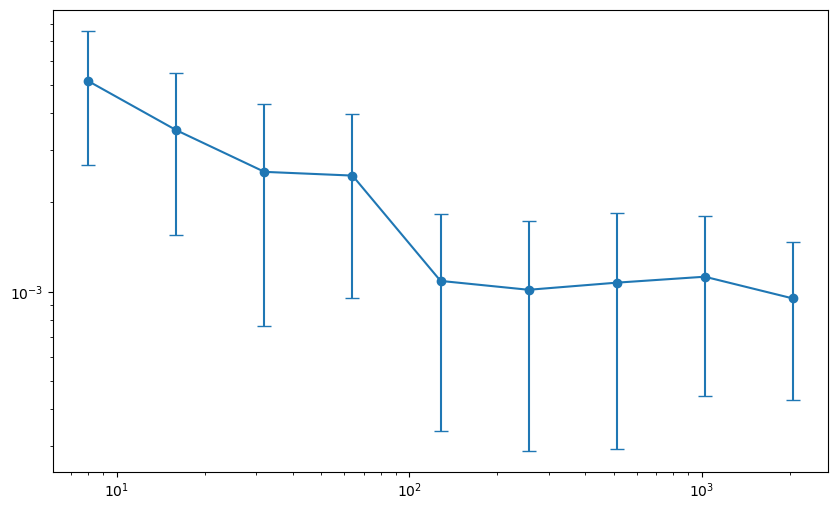

In [8]:
plt.figure(figsize=(10, 6))
p = rmse.groupby(['max_bin_size'])['rmse'].agg(['mean', 'std'])
plt.errorbar(
    p.index, 
    p['mean'], 
    yerr=p['std'], 
    fmt='-o', 
    capsize=5, 
    label='ALE Exact', 
    color='tab:blue'
)
plt.yscale('log')
plt.xscale('log')

In [40]:
df.tail(20)

,i,k,max_bin_size,ALE exact,time_exact,ALE approximate,time_approximate,n_layers,hidden_size,no_exp,explanation
635,0,1024,1024,-0.002753,188.118213,-0.002152,0.444294,2,256,2,127.0
636,1,1024,1024,-0.004728,188.118213,-0.003978,0.444294,2,256,2,127.0
637,2,1024,1024,-0.006611,188.118213,-0.006299,0.444294,2,256,2,127.0
638,3,1024,1024,-0.006611,188.118213,-0.006299,0.444294,2,256,2,127.0
639,4,1024,1024,-0.007659,188.118213,-0.007453,0.444294,2,256,2,127.0
640,0,1024,1024,-0.002907,191.373525,-0.002610,0.454721,2,256,2,128.0
641,1,1024,1024,-0.005111,191.373525,-0.005069,0.454721,2,256,2,128.0
642,2,1024,1024,-0.007667,191.373525,-0.007629,0.454721,2,256,2,128.0
643,3,1024,1024,-0.007667,191.373525,-0.007629,0.454721,2,256,2,128.0
644,4,1024,1024,-0.009118,191.373525,-0.008732,0.454721,2,256,2,128.0


# Depth analysis

In [72]:
import pandas as pd
depth = pd.read_csv('../data/citations/ALE_depth_GAT3.csv', names=['i', 'k', 'max_bin_size', 'ALE exact', 'time_exact', 'ALE approximate', 'time_approximate', 'n_layers', 'hidden_size', 'no_exp', 'trial'])

In [73]:
import numpy as np
depth['trial'] = np.floor(depth.index/5)

In [74]:
depth['mse'] = (depth['ALE exact']-depth['ALE approximate'])**2

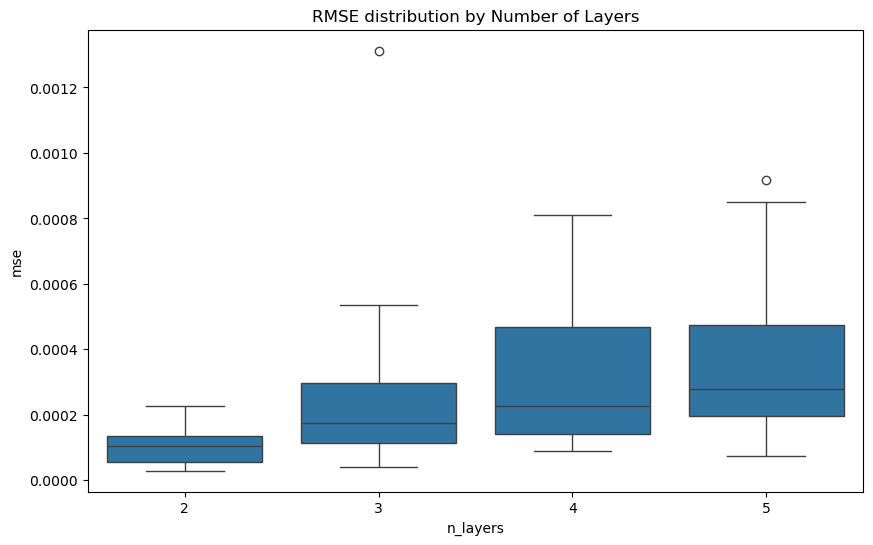

In [75]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Recommended

# 1. Prepare the aggregated data
df_agg = (depth.groupby(['trial', 'no_exp', 'n_layers', 'hidden_size', 'k'])['mse']
          .mean()
          .apply(np.sqrt)
          .reset_index())

plt.figure(figsize=(10, 6))

sns.boxplot(data=df_agg, x='n_layers', y='mse')

plt.title('RMSE distribution by Number of Layers')
plt.show()

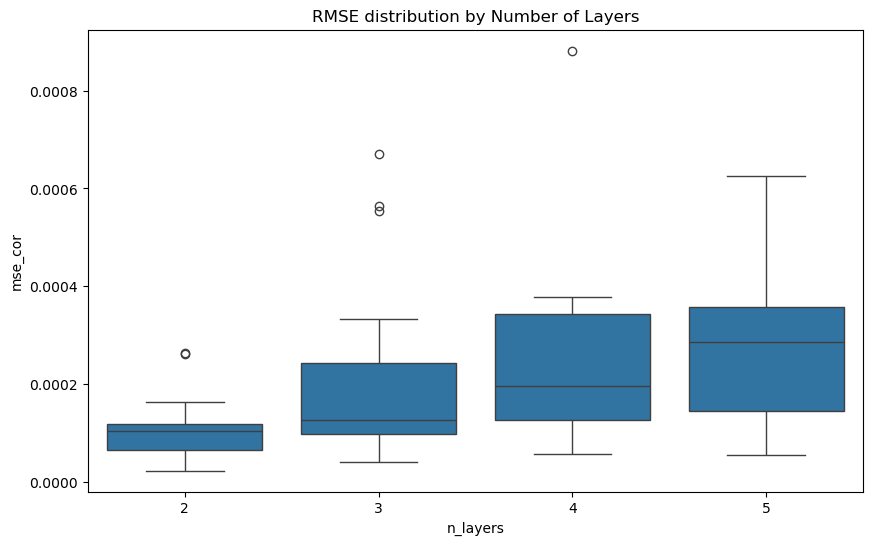

In [76]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Recommended
gt = depth.groupby(['i', 'no_exp', 'n_layers', 'hidden_size', 'k'])['ALE exact'].mean()
depth['mse_cor'] = (depth.apply(lambda x: x['ALE approximate'] - gt.loc[(x['i'], x['no_exp'], x['n_layers'], x['hidden_size'], x['k'])],axis=1))**2
# 1. Prepare the aggregated data
df_agg = (depth.groupby(['trial', 'no_exp', 'n_layers', 'hidden_size', 'k'])['mse_cor']
          .mean()
          .apply(np.sqrt)
          .reset_index())

plt.figure(figsize=(10, 6))

sns.boxplot(data=df_agg, x='n_layers', y='mse_cor')

plt.title('RMSE distribution by Number of Layers')
plt.show()

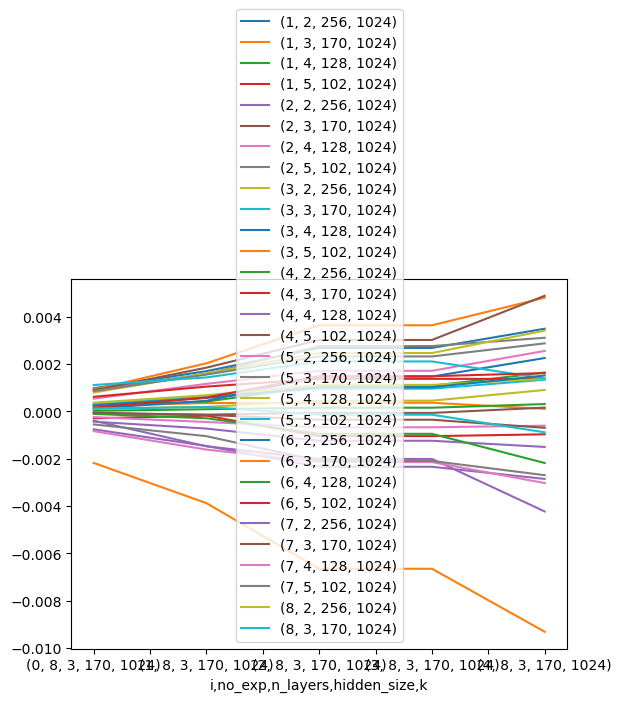

In [77]:
gt.groupby(['no_exp', 'n_layers', 'hidden_size', 'k']).plot(x='i', y='ALE exact')
plt.legend()
plt.show()

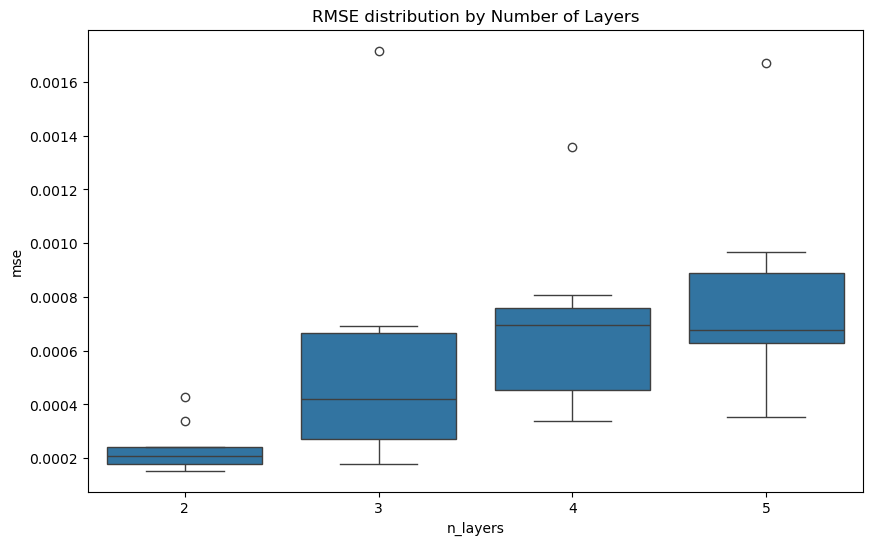

In [78]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Recommended

# 1. Prepare the aggregated data
df_agg = (depth.groupby(['trial', 'no_exp', 'n_layers', 'hidden_size', 'k'])['mse']
          .sum()
          .apply(np.sqrt)
          .reset_index())
df_stat = df_agg.groupby(['no_exp', 'n_layers', 'hidden_size', 'k'])['mse'].mean().reset_index()
plt.figure(figsize=(10, 6))

sns.boxplot(data=df_stat, x='n_layers', y='mse')

plt.title('RMSE distribution by Number of Layers')
plt.show()

<Figure size 1000x600 with 0 Axes>

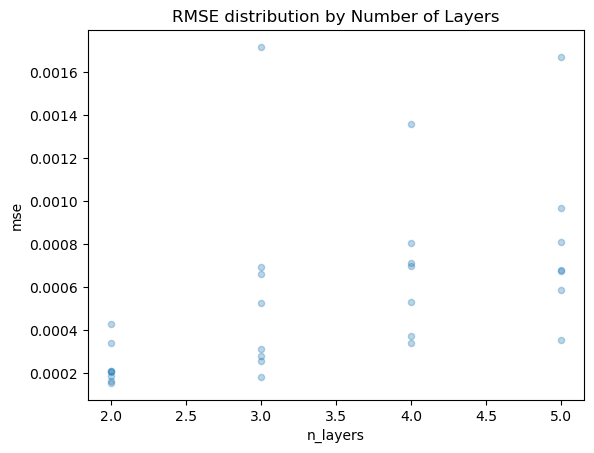

In [82]:
plt.figure(figsize=(10, 6))

df_stat.plot.scatter(x='n_layers', y='mse',alpha=0.3)

plt.title('RMSE distribution by Number of Layers')
plt.show()

In [ ]:
import numpy as np

# 1. Calculate the mean of the ALE values for each group
# This aggregates over the columns not present in the groupby (e.g., 'trial')
df_agg = depth.groupby(['i', 'no_exp', 'n_layers'])[['ALE exact']].mean()

# 2. Calculate the RMSE from these aggregated values
# Formula: sqrt( (Mean_Exact - Mean_Approx)^2 )
depth['rmse'] = depth.apply(lambda x: x['ALE approximate']-df_agg.loc[(x['i'], x['no_exp'], x['n_layers'])], axis=1)



   i  no_exp  n_layers  ALE exact
0  0       0         2   0.001949
1  0       0         3   0.001016
2  0       0         4  -0.002106
3  0       0         5   0.000304
4  0       1         2   0.001654


In [ ]:
# 1. Prepare the aggregated data
df_agg = (depth.groupby(['trial', 'no_exp', 'n_layers', 'hidden_size', 'k'])['mse']
          .sum()
          .apply(np.sqrt)
          .reset_index())

plt.figure(figsize=(10, 6))

sns.boxplot(data=df_agg, x='n_layers', y='mse')

plt.title('RMSE distribution by Number of Layers')
plt.show()

,no_exp,n_layers,rmse
0,0,2,0.013804
1,0,3,NaN
2,0,4,0.123504
3,0,5,0.057930
4,1,2,0.022173
5,1,3,NaN
6,1,4,0.123505
7,1,5,0.057933
8,2,2,0.122556
9,2,3,NaN


<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

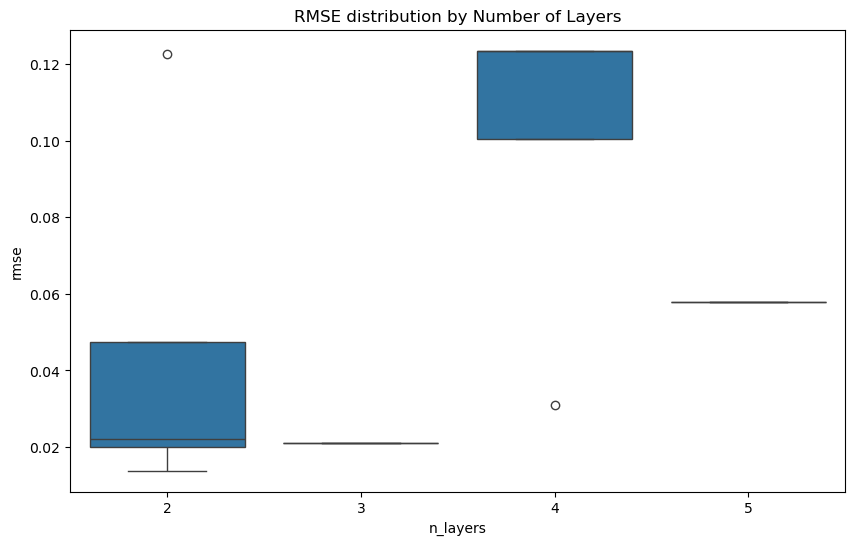

In [ ]:
plt.figure(figsize=(10, 6))
df_agg = depth.groupby(['no_exp', 'n_layers'])['rmse'].sum().apply(np.sqrt).reset_index()
sns.boxplot(data=df_agg, x='n_layers', y='rmse')

plt.title('RMSE distribution by Number of Layers')
plt.show()

In [ ]:
depth.groupby(['trial', 'no_exp', 'n_layers', 'hidden_size', 'k'])['rmse'].sum().apply(np.sqrt).reset_index().groupby('n_layers').boxplot('rmse')

,trial,no_exp,hidden_size,k,rmse
n_layers,,,,,
2,42.0,2.0,256.0,1024.0,0.001112
3,47.0,2.0,170.0,1024.0,0.000806
4,52.0,2.0,128.0,1024.0,0.001606
5,57.0,2.0,102.0,1024.0,0.001188
